In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../files/train.csv')
test_df = pd.read_csv('../files/test.csv')

In [244]:
# columns
print(train_df.columns.values)
print(test_df.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']
['PassengerId' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch' 'Ticket' 'Fare'
 'Cabin' 'Embarked']


In [245]:
# dimension
print(train_df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


In [246]:
# check if dataset contains missing data

print("Train df\n", train_df.isna().sum())
print("\nTest df\n", test_df.isna().sum())

Train df
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test df
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [247]:
print(train_df.info())
print("\n")
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   P

In [248]:
# Identify the unique values of the categorical features (Sex, Embarked)
print(train_df['Sex'].unique())
print(train_df['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q' nan]


In [249]:
# Get the main statistics of numerical features

print(train_df.describe())
print(train_df.describe(include=['O']))

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
                           Name   Sex  Ticket    Cabin Embarked
count            

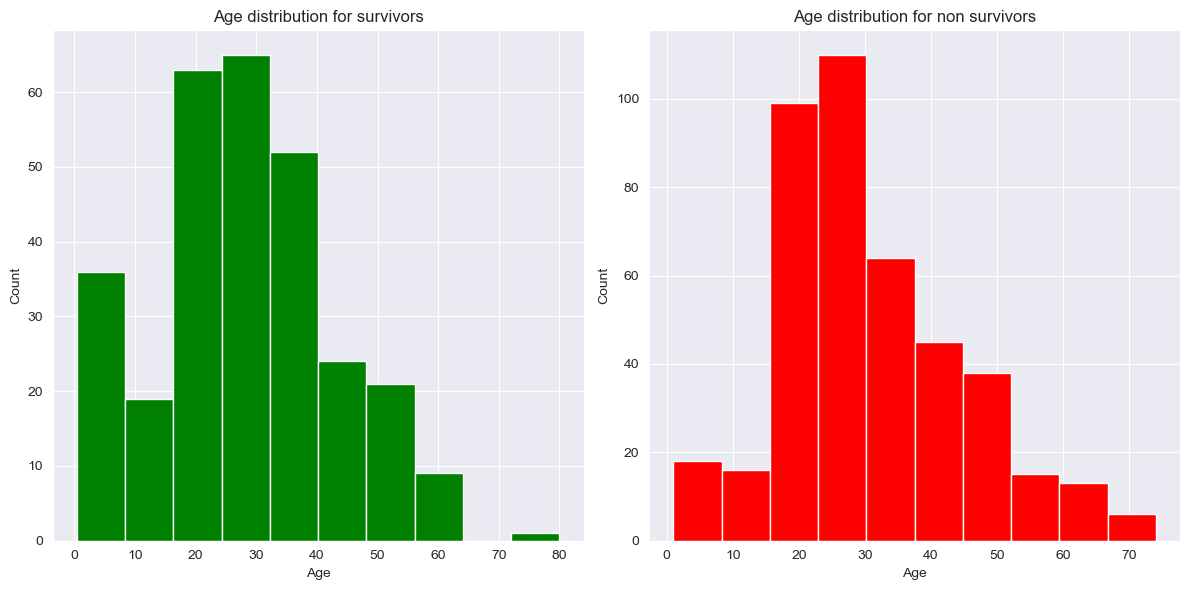

Mean age of survivors:
 Age    28.34369
dtype: float64
Mean age of non survivors:
 Age    30.626179
dtype: float64


In [250]:
# survivors and non survivors by age
survived_df = train_df[train_df['Survived'] == 1][['Age']]
not_survived_df = train_df[train_df['Survived'] == 0][['Age']]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(survived_df['Age'].dropna(), color='green')
plt.title('Age distribution for survivors')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(not_survived_df['Age'].dropna(), color='red')
plt.title('Age distribution for non survivors')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print('Mean age of survivors:\n', survived_df.mean())
print('Mean age of non survivors:\n', not_survived_df.mean())
# Most passengers are in 15-35 age range.
# Children had high survival rate

        Survived
Sex             
female  0.742038
male    0.188908


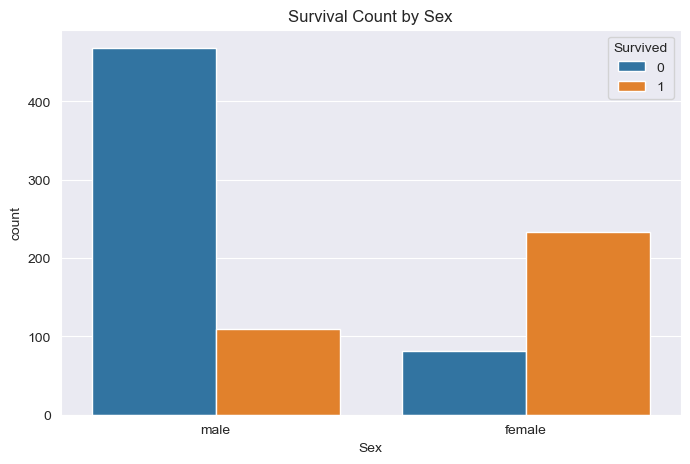

        Survived
Pclass          
1       0.629630
2       0.472826
3       0.242363


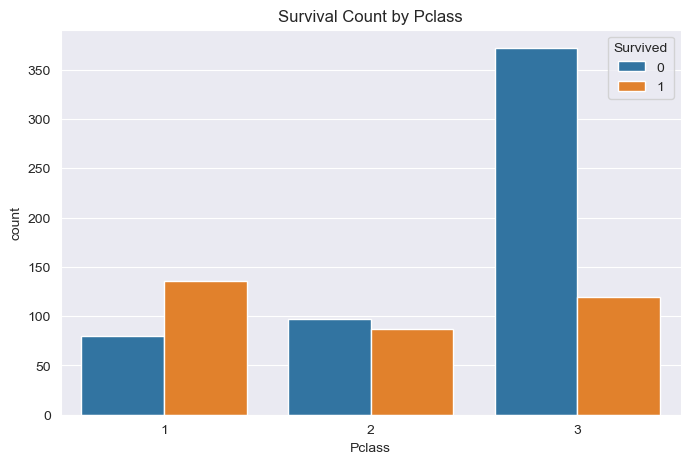

          Survived
Embarked          
C         0.553571
Q         0.389610
S         0.336957


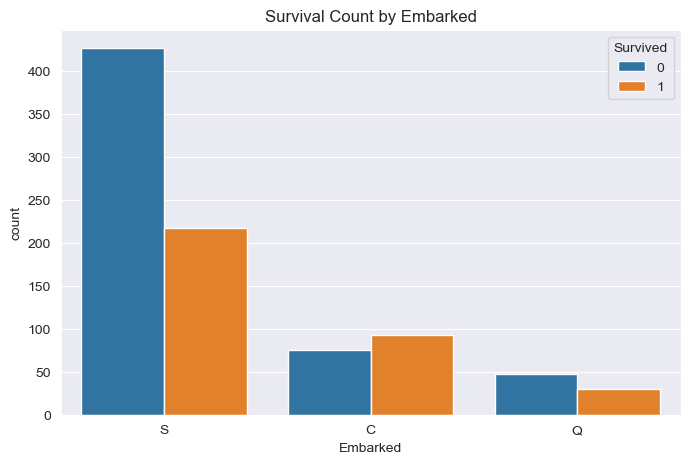

In [251]:
# plot each categorical feature and calculate survival rate
categorical_features = ['Sex', 'Pclass', 'Embarked']

for feature in categorical_features:
    print(train_df[[feature, 'Survived']].groupby([feature]).mean())

    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Survived', data=train_df)
    plt.title('Survival Count by ' + feature)
    plt.show()

# Female passengers had much better survival rate than males.
# Most passengers in Pclass=1 survived
# Port of embarkation may correlate with survival rate

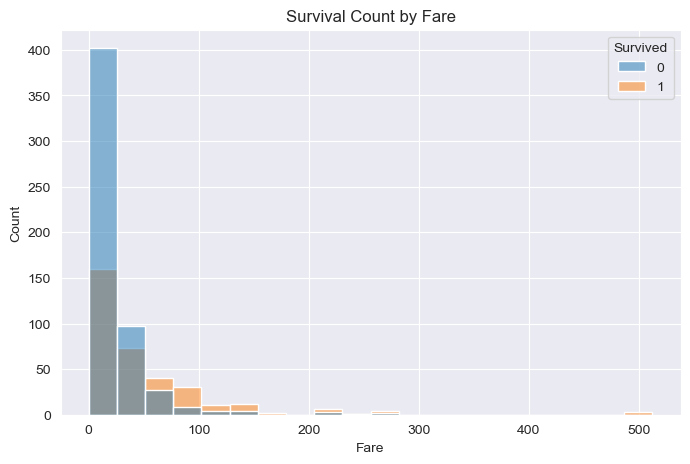

In [252]:
# plots for numerical features

plt.figure(figsize=(8, 5))
sns.histplot(data=train_df, x='Fare', hue='Survived', bins=20)
plt.title('Survival Count by Fare')
plt.show()

   Pclass     Sex  Survived
0       1  female  0.968085
1       1    male  0.368852
2       2  female  0.921053
3       2    male  0.157407
4       3  female  0.500000
5       3    male  0.135447


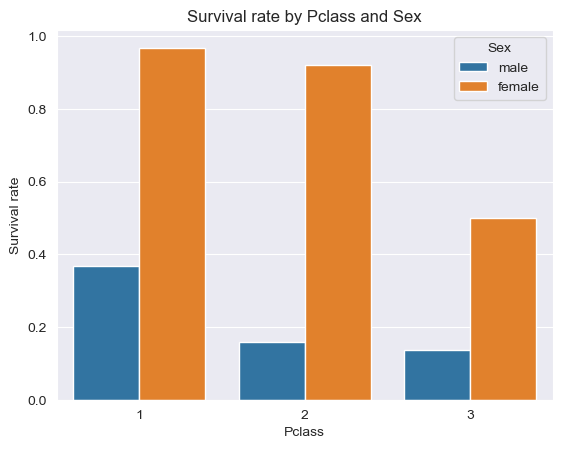

In [253]:
# Survival rate by pclass and sex
survival_rate_by_pclass_and_sex = train_df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
print(survival_rate_by_pclass_and_sex)

sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', errorbar=None)
plt.title("Survival rate by Pclass and Sex")
plt.ylabel("Survival rate")
plt.show()

In [254]:
# drop Cabin and Ticket features on both datasets (duplicates/too many missing values)
# drop Name as it seems there is no apparent correlation with survival
# drop PassengerId on training dataset (because it's useless)

train_df = train_df.drop(['Ticket', 'Cabin', 'PassengerId', 'Name'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin', 'Name'], axis=1)

# print(train_df.shape, test_df.shape)

In [255]:
# impute age missing values

def impute_age(df, median_ages):
    df['Age'] = df.apply(
        lambda row: median_ages.loc[row['Pclass'], row['Sex']] if pd.isnull(row['Age']) else row['Age'], axis=1)
    return df


# calculate the median age for each combination of pclass and sex in the training set and test set
median_ages_train = train_df.groupby(['Pclass', 'Sex'])['Age'].median()
median_ages_test = test_df.groupby(['Pclass', 'Sex'])['Age'].median()

train_df = impute_age(train_df, median_ages_train)
test_df = impute_age(test_df, median_ages_test)

print(median_ages_train)
print("\n")
print(median_ages_test)

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


Pclass  Sex   
1       female    41.0
        male      42.0
2       female    24.0
        male      28.0
3       female    22.0
        male      24.0
Name: Age, dtype: float64


In [256]:
# fill embark missing values from training dataset with most frequent value

most_freq = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(most_freq)

In [257]:
# fill Fare missing value on test dataset

fare_value = test_df['Fare'].mean()
fare_value = round(fare_value, 2)
test_df['Fare'].fillna(value=fare_value, inplace=True)

In [258]:
# DUMMY ENCODING sex column
# male : 1, female : 0

def process_sex_column(df):
    df = pd.get_dummies(data=df, columns=['Sex'], drop_first=True)
    df.rename(columns={'Sex_male': 'Sex'}, inplace=True)
    return df


train_df = process_sex_column(train_df)
test_df = process_sex_column(test_df)

# train_df.head(5)

In [259]:
# ONE HOT ENCONDING embarked column

train_df = pd.get_dummies(train_df, columns=['Embarked'])
test_df = pd.get_dummies(test_df, columns=['Embarked'])

# train_df.head(5)

In [260]:
# create new feature isAlone (with this we can drop SibSp and Parch features)

# if train_df['SibSp'] + train_df['Parch'] == 0 then isAlone = 1 else isAlone = 0
train_df['isAlone'] = np.where((train_df['SibSp'] + train_df['Parch']) == 0, 1, 0)
test_df['isAlone'] = np.where((test_df['SibSp'] + test_df['Parch']) == 0, 1, 0)

# survival rate for isAlone
print(train_df[['isAlone', 'Survived']].groupby(['isAlone']).mean().sort_values(by='Survived', ascending=False))

train_df.drop(['SibSp', 'Parch'], axis=1, inplace=True)
test_df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

         Survived
isAlone          
0        0.505650
1        0.303538


In [261]:
print(train_df.head(5))
print("\n")
print(test_df.head(5))

   Survived  Pclass   Age     Fare  Sex  Embarked_C  Embarked_Q  Embarked_S  \
0         0       3  22.0   7.2500    1           0           0           1   
1         1       1  38.0  71.2833    0           1           0           0   
2         1       3  26.0   7.9250    0           0           0           1   
3         1       1  35.0  53.1000    0           0           0           1   
4         0       3  35.0   8.0500    1           0           0           1   

   isAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


   PassengerId  Pclass   Age     Fare  Sex  Embarked_C  Embarked_Q  \
0          892       3  34.5   7.8292    1           0           1   
1          893       3  47.0   7.0000    0           0           0   
2          894       2  62.0   9.6875    1           0           1   
3          895       3  27.0   8.6625    1           0           0   
4          896       3  22.0  12.2875    0           0           0   

   Embarked_S  isAlone  

META 2

In [286]:
# separate features and label

from sklearn.preprocessing import StandardScaler

X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']

# X_test = test_df

# apply standardScaler because of the performance of some algorithms (LogisticRegression, k-NN and SVM)
X_train = StandardScaler().fit_transform(X_train)

In [287]:
# cross-validation, k-folds = 10
# test list of models to check which ones to use for ensemble

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42

classifiers = [
    LogisticRegression(random_state=random_state),
    SVC(random_state=random_state),
    DecisionTreeClassifier(random_state=random_state),
    RandomForestClassifier(random_state=random_state),
    KNeighborsClassifier(),
    GaussianNB(),
    MLPClassifier(random_state=random_state)
]

cv_results = []
cv_means = []
cv_std = []

for classifier in classifiers:
    scores = cross_val_score(estimator=classifier, X=X_train, y=y_train, scoring="accuracy", cv=10)
    cv_results.append(scores)
    cv_means.append(scores.mean())
    cv_std.append(scores.std())
    print(f"{classifier.__class__.__name__}: Accuracy: {scores.mean():.3f}, Standard Deviation: {scores.std():.3f}")


LogisticRegression: Accuracy: 0.790, Standard Deviation: 0.025
SVC: Accuracy: 0.823, Standard Deviation: 0.034
DecisionTreeClassifier: Accuracy: 0.786, Standard Deviation: 0.049
RandomForestClassifier: Accuracy: 0.809, Standard Deviation: 0.042
KNeighborsClassifier: Accuracy: 0.795, Standard Deviation: 0.033
GaussianNB: Accuracy: 0.745, Standard Deviation: 0.053
MLPClassifier: Accuracy: 0.811, Standard Deviation: 0.029


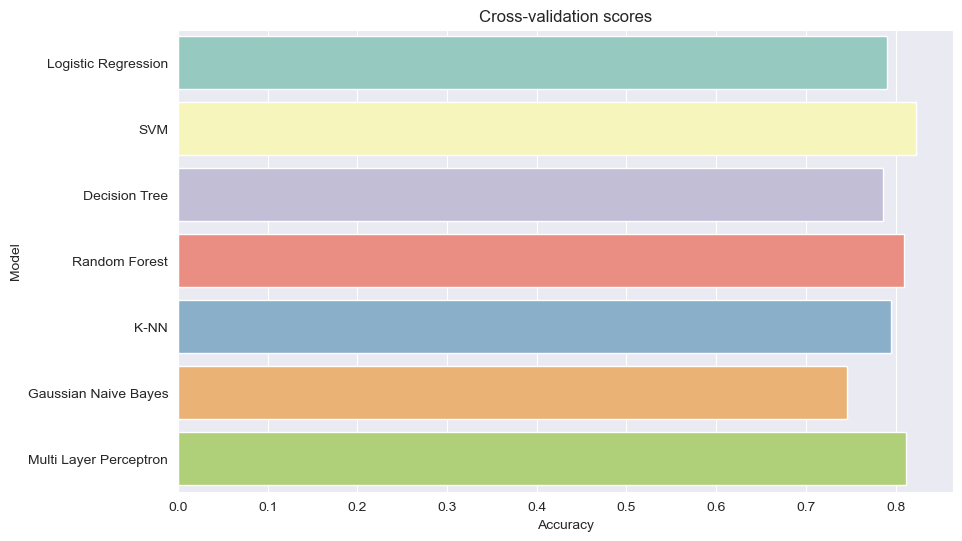

In [289]:
# barplot to compare the accuracy of the models

cv_res = pd.DataFrame({
    "Accuracy": cv_means,
    "Model": [
        "Logistic Regression", "SVM", "Decision Tree", "Random Forest", "K-NN", "Gaussian Naive Bayes",
        "Multi Layer Perceptron"
    ]
})

plt.figure(figsize=(10, 6))
cv_chart = sns.barplot(x="Accuracy", y="Model", data=cv_res, palette="Set3", orient="h")
cv_chart.set_xlabel("Accuracy")
cv_chart.set_title("Cross-validation scores")
plt.show()

In [290]:
# select top 5 models based on accuracy

top_models_indices = np.argsort(cv_means)[::-1][:5]
top_models = [classifiers[i] for i in top_models_indices]
print(top_models)

[SVC(random_state=42), MLPClassifier(random_state=42), RandomForestClassifier(random_state=42), KNeighborsClassifier(), LogisticRegression(random_state=42)]


In [306]:
# define list of hyperparameters to tune for each model

# logistic regression
param_grid_lr = {'fit_intercept': [True, False], 'solver': ['lbfgs', 'newton-cg'], 'penalty': ['l2'],
                 'max_iter': [4000], 'random_state': [42], 'n_jobs': [2]}
# SVM
param_grid_svc = {'gamma': ['scale', 'auto'], 'random_state': [42]}
# random forest
param_grid_rf = {'n_estimators': [100, 150, 200], 'max_depth': [4, 8, 16], 'min_samples_split': [2, 4, 6],
                 'min_samples_leaf': [1, 2, 4], 'random_state': [42], 'n_jobs': [2]}
# K-NN
param_grid_knn = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance'], 'p': [1, 2], 'n_jobs': [2]}
# MLP
param_grid_mlp = {'hidden_layer_sizes': [(100,), (50, 50), (25, 50, 25)], 'activation': ['relu', 'tanh', 'logistic'],
                  'max_iter': [4000], 'random_state': [42]}

param_grids = [param_grid_svc, param_grid_mlp, param_grid_rf, param_grid_knn, param_grid_lr]

In [307]:
# grid search to tune hyperparameters

from sklearn.model_selection import GridSearchCV

top_models_tuned = []
cv_results_tuned = []
cv_means_tuned = []
cv_std_tuned = []

for i, model in enumerate(top_models):
    param_grid = param_grids[i]

    grid_search = GridSearchCV(model, param_grid, cv=10, scoring='accuracy', n_jobs=2)
    grid_search.fit(X_train, y_train)

    top_models_tuned.append(grid_search.best_estimator_)

    cv_results = grid_search.cv_results_['mean_test_score']
    cv_results_tuned.append(cv_results)
    cv_means_tuned.append(grid_search.best_score_)
    cv_std_tuned.append(grid_search.cv_results_['std_test_score'][grid_search.best_index_])

    print(f"Best hyperparameters for {model.__class__.__name__}: {grid_search.best_params_}")
    print(
        f"{model.__class__.__name__}: Accuracy: {grid_search.best_score_:.3f}, Standard Deviation: {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.3f}")


Best hyperparameters for SVC: {'gamma': 'scale', 'random_state': 42}
SVC: Accuracy: 0.823, Standard Deviation: 0.034
Best hyperparameters for MLPClassifier: {'activation': 'relu', 'hidden_layer_sizes': (25, 50, 25), 'max_iter': 4000, 'random_state': 42}
MLPClassifier: Accuracy: 0.813, Standard Deviation: 0.033
Best hyperparameters for RandomForestClassifier: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 100, 'n_jobs': 2, 'random_state': 42}
RandomForestClassifier: Accuracy: 0.829, Standard Deviation: 0.045
Best hyperparameters for KNeighborsClassifier: {'n_jobs': 2, 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
KNeighborsClassifier: Accuracy: 0.804, Standard Deviation: 0.035
Best hyperparameters for LogisticRegression: {'fit_intercept': True, 'max_iter': 4000, 'n_jobs': 2, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs'}
LogisticRegression: Accuracy: 0.790, Standard Deviation: 0.025


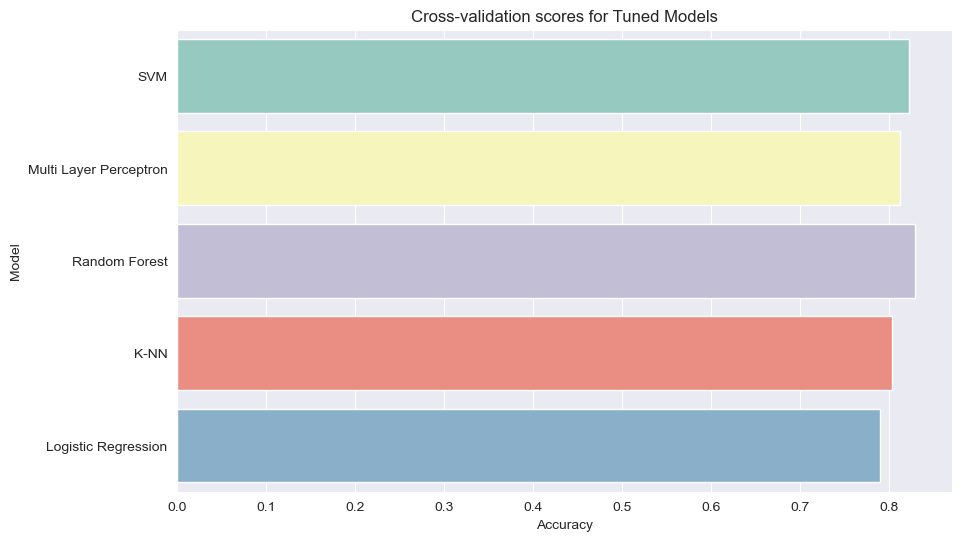

In [308]:
# barplot to compare the accuracy of the tuned models

cv_res_tuned = pd.DataFrame({
    "Accuracy": cv_means_tuned,
    "Model": [
        "SVM", "Multi Layer Perceptron", "Random Forest", "K-NN", "Logistic Regression"
    ]
})

plt.figure(figsize=(10, 6))
cv_chart_tuned = sns.barplot(x="Accuracy", y="Model", data=cv_res_tuned, palette="Set3", orient="h")
cv_chart_tuned.set_xlabel("Accuracy")
cv_chart_tuned.set_title("Cross-validation scores for Tuned Models")
plt.show()


In [ ]:
# aplicar ensemble com voting

# from sklearn.ensemble import VotingClassifier


# svc_classifier = SVC(random_state=random_state)
# rf_classifier = RandomForestClassifier(random_state=random_state)
# knn_classifier = KNeighborsClassifier()
# 
# # Voting classifier
# voting_classifier = VotingClassifier(
#     estimators=[
#         ('svc', classifiers[1]),
#         ('random_forest', classifiers[3]),
#         ('knn', classifiers[4])
#     ],
#     voting='hard'  # 'hard' for majority voting, 'soft' for weighted voting
# )
# 
# # Cross-validation for the voting classifier
# cv_results_voting = cross_val_score(
#     estimator=voting_classifier, X=X_train, y=y_train, scoring="accuracy", cv=10
# )
# 
# # Print the results
# print(f"Voting Classifier: Accuracy: {cv_results_voting.mean():.4f}, Standard Deviation: {cv_results_voting.std():.4f}")
